In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/jopacc_system_month_november_2022_to_june_2026.csv")

In [3]:
df["report_month"] = pd.to_datetime(df["report_month"])

# select system and 12 months

In [4]:
selected = df[(df["system"] == "eFAWATEERcom") &(df["report_month"] >= "2025-07-01") &(df["report_month"] <= "2026-06-01")].copy()

In [5]:
selected = selected.sort_values("report_month")

indicator = "transactions_total"

print("The 12 months:")
print(selected[["report_month", indicator]])

The 12 months:
    report_month  transactions_total
158   2025-07-01             6580000
163   2025-08-01             6640000
168   2025-09-01             6450000
173   2025-10-01             6690000
178   2025-11-01             6520000
183   2025-12-01             7030000
188   2026-01-01             6530000
193   2026-02-01             6580000
198   2026-03-01             7360000
203   2026-04-01             6590000
208   2026-05-01             6860000
213   2026-06-01             7060000


# Sort values lowest to highest

In [6]:
ranked = selected.sort_values(by=[indicator, "report_month"]).copy()

ranked["activity_level"] = (
    ["Low"] * 3 +
    ["Medium"] * 3 +
    ["High"] * 3 +
    ["Very High"] * 3)

print("\nSorted values and assigned activity levels:")
print(ranked[["report_month", indicator, "activity_level"]].to_string(index=False))



Sorted values and assigned activity levels:
report_month  transactions_total activity_level
  2025-09-01             6450000            Low
  2025-11-01             6520000            Low
  2026-01-01             6530000            Low
  2025-07-01             6580000         Medium
  2026-02-01             6580000         Medium
  2026-04-01             6590000         Medium
  2025-08-01             6640000           High
  2025-10-01             6690000           High
  2026-05-01             6860000           High
  2025-12-01             7030000      Very High
  2026-06-01             7060000      Very High
  2026-03-01             7360000      Very High


# ordered table :)

In [9]:
selected["activity_level"] = selected["report_month"].map(ranked.set_index("report_month")["activity_level"])


print("\nOrdered activity table:")
print(
    selected[["Month", "transactions_total", "activity_level"]].to_string(index=False))


Ordered activity table:
   Month  transactions_total activity_level
 Month 1             6580000         Medium
 Month 2             6640000           High
 Month 3             6450000            Low
 Month 4             6690000           High
 Month 5             6520000            Low
 Month 6             7030000      Very High
 Month 7             6530000            Low
 Month 8             6580000         Medium
 Month 9             7360000      Very High
Month 10             6590000         Medium
Month 11             6860000           High
Month 12             7060000      Very High


# Month to month transitions

In [10]:
levels = selected["activity_level"].tolist()

trans = list(zip(levels[:-1], levels[1:]))

print("\nAll month-to-month transitions:")

for transition in trans:
    print(transition)


All month-to-month transitions:
('Medium', 'High')
('High', 'Low')
('Low', 'High')
('High', 'Low')
('Low', 'Very High')
('Very High', 'Low')
('Low', 'Medium')
('Medium', 'Very High')
('Very High', 'Medium')
('Medium', 'High')
('High', 'Very High')


# Directed unweighted Graph

In [11]:
G = nx.DiGraph()

activity_levels = [
    "Low",
    "Medium",
    "High",
    "Very High"]

G.add_nodes_from(activity_levels)

for source, target in trans:
    G.add_edge(source, target)

print("\nUnique unweighted edges:")
print(list(G.edges()))



Unique unweighted edges:
[('Low', 'High'), ('Low', 'Very High'), ('Low', 'Medium'), ('Medium', 'High'), ('Medium', 'Very High'), ('High', 'Low'), ('High', 'Very High'), ('Very High', 'Low'), ('Very High', 'Medium')]


# Vizualize!!!

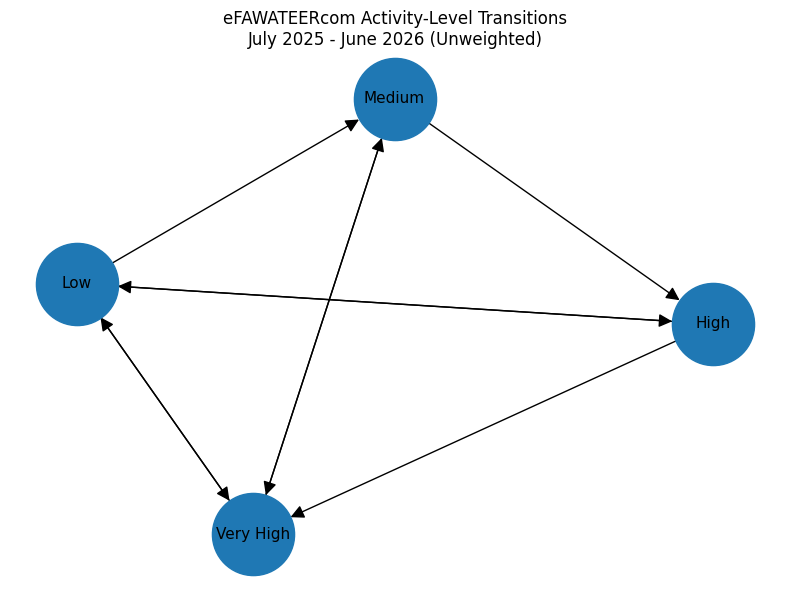

In [12]:
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    font_size=11,
    arrows=True,
    arrowsize=20)

plt.title(
    "eFAWATEERcom Activity-Level Transitions\n"
    "July 2025 - June 2026 (Unweighted)")

plt.axis("off")
plt.tight_layout()

plt.show()

# **Directed weighted graph**

In [13]:
from collections import Counter
transition_counts = Counter(trans)

print("\nTransition frequencies:")

for transition, frequency in transition_counts.items():
    print(transition, "=", frequency)


WG = nx.DiGraph()

WG.add_nodes_from(activity_levels)

for (source, target), weight in transition_counts.items():
    WG.add_edge(source,target,weight=weight)


Transition frequencies:
('Medium', 'High') = 2
('High', 'Low') = 2
('Low', 'High') = 1
('Low', 'Very High') = 1
('Very High', 'Low') = 1
('Low', 'Medium') = 1
('Medium', 'Very High') = 1
('Very High', 'Medium') = 1
('High', 'Very High') = 1


# Vizualizations

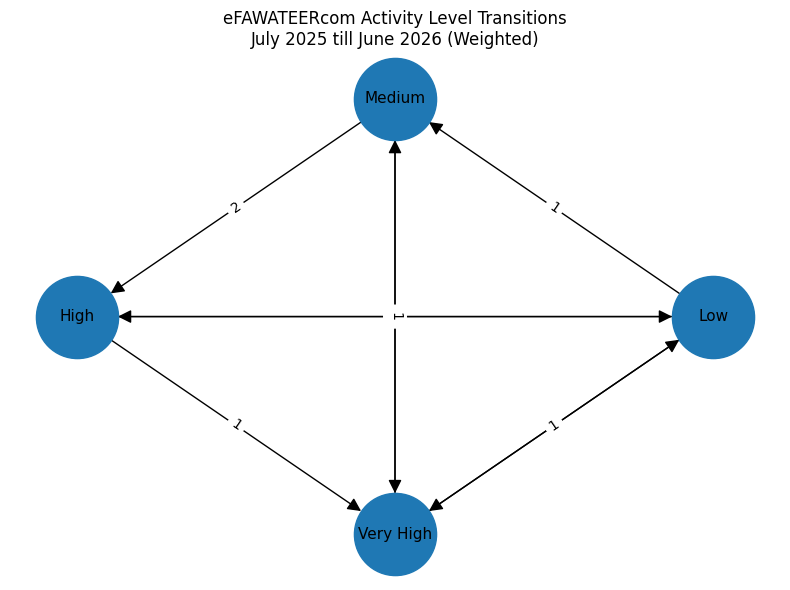

In [14]:
pos = nx.circular_layout(WG)

weights = [
WG[u][v]["weight"]
    for u, v in WG.edges()]

plt.figure(figsize=(8, 6))

nx.draw_networkx(WG,pos,with_labels=True,node_size=3500,font_size=11,arrows=True,arrowsize=20)

edge_labels = nx.get_edge_attributes(WG,"weight")

nx.draw_networkx_edge_labels(WG,pos,edge_labels=edge_labels,font_size=10)

plt.title(
    "eFAWATEERcom Activity Level Transitions\n"
    "July 2025 till June 2026 (Weighted)")

plt.axis("off")
plt.tight_layout()

plt.show()


# graph measures

In [17]:
indegree = dict(WG.in_degree(weight="weight"))

outdegree = dict(WG.out_degree(weight="weight"))

pagerank = nx.pagerank(WG,alpha=0.85,weight="weight")

incloseness = nx.closeness_centrality(WG)
outcloseness = nx.closeness_centrality(WG.reverse())

betweenness = nx.betweenness_centrality(WG,normalized=True,weight=None)

weighted_results = pd.DataFrame({
    "In degree": indegree,
    "Out degree": outdegree,
    "Weighted PageRank": pagerank,
    "In Closeness": incloseness,
    "Out Closeness": outcloseness,
    "Betweenness": betweenness})

print("\nweighted graph results:")
weighted_results


weighted graph results:


,In degree,Out degree,Weighted PageRank,In Closeness,Out Closeness,Betweenness
Low,3,3,0.282124,0.75,1.00,0.166667
Medium,2,3,0.223685,0.75,0.75,0.083333
High,3,3,0.244190,0.75,0.75,0.083333
Very High,3,2,0.250000,1.00,0.75,0.166667
